# Data Preparation

Load all necessary packages for this notebook.

In [1]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image

import tensorflow as tf #tensorflow machine learning libarary
import numpy as np  #numpy allows us to use an efficient matrix representation
import timeit #to time execution of routines
import time
import os
import zipfile #to unzip the dataset

import keras
from keras import metrics
import matplotlib.pyplot as plt
from tensorflow.python.keras.backend import dropout  #to plot the results
from tensorflow.keras.regularizers import l2

from skimage.transform import rotate

plt.rcParams["figure.figsize"] = (24, 12)

In [2]:
# Cropping Constants
BINARY_THRESHOLD = 1
RUN_THRESHOLD = 0.18
MIN_HEIGHT = 300

# Artifacts Constants
ARTIFACT_INTENSITY = 220

Here are the functions based on what we've explored above.

In [3]:
def load_image(image_path):
    img = cv2.imread(image_path, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img_rgb

def crop_image(image_array, window_size):
    ultrasound_image = find_ultrasound_image(image_array)
    cropped_image = standardize_size(ultrasound_image, window_size)
    return cropped_image

def remove_artifacts(cropped_image):
    artifact_flags = cropped_image >= ARTIFACT_INTENSITY
    artifact_idx = np.where(artifact_flags)
    artifact_idx_list = []
    for i, y in enumerate(artifact_idx[0]):
        x = artifact_idx[1][i]
        artifact_idx_list.append((y, x, cropped_image[y, x]))
    artifact_idx_list.sort(key=lambda tup: tup[2], reverse=False)
    for y, x, _ in artifact_idx_list:
        local_region = cropped_image[(y-1):(y+2), (x-1):(x+2)]
        background_mean = np.mean(sorted(local_region.flatten())[:6])
        cropped_image[y, x] = background_mean
    return cropped_image

def find_ultrasound_image(image_array):
    binary_mask = np.zeros(image_array.shape)
    binary_mask[image_array > BINARY_THRESHOLD] = 1.
    
    row_mean = np.mean(binary_mask, axis=0)
    col_mean = np.mean(binary_mask, axis=1)
    
    row_runs = get_bidirectional_runs(row_mean)
    col_runs = get_bidirectional_runs(col_mean)
    
    row_indices = np.where(row_runs >= np.max(row_runs)*0.75)[0]
    left_bound = row_indices[0]
    right_bound = row_indices[-1]
    col_indices = np.where(col_runs >= np.max(col_runs)*0.75)[0]
    up_bound = col_indices[0]
    down_bound = max(col_indices[-1], up_bound + MIN_HEIGHT)
    cropped_image = image_array[up_bound:down_bound, left_bound:right_bound]
    
    return cropped_image

def standardize_size(ultrasound_image, window_size):
    resized_image = np.zeros(window_size)
    horizontal_boundary = int((window_size[1] - ultrasound_image.shape[1])/2)
    vertical_boundary = int((window_size[0] - ultrasound_image.shape[0])/2)
    resized_image[vertical_boundary:(vertical_boundary+ultrasound_image.shape[0]), 
                  horizontal_boundary:(horizontal_boundary+ultrasound_image.shape[1])] = ultrasound_image
    return resized_image

def get_bidirectional_runs(mean_vector):
    forward_runs = get_runs(mean_vector)
    backward_runs = get_runs(mean_vector[::-1])[::-1]
    bidirectional_runs = forward_runs + backward_runs
    return bidirectional_runs

def get_runs(numeric_vector):
    runs = np.empty(len(numeric_vector), dtype=np.int16)
    curr = 0
    for i, x in enumerate(numeric_vector):
        if x > RUN_THRESHOLD:
            curr += 1
        else:
            curr = 0
        runs[i] = curr
    return runs

def represents_int(s):
    try: 
        int(s)
        return True
    except ValueError:
        return False

In [4]:
data_path = os.path.join('..', 'data')
samples = os.listdir(data_path)
if 'aggregate.csv' in samples:
    samples.remove('aggregate.csv')

csv_path=os.path.join('..', 'data', 'aggregate.csv')
image_data= pd.read_csv(csv_path, usecols=['sample_id','image','echo_score'])



Use the functions above to process the images.

In [5]:
sample_id=image_data.sample_id
image=image_data.image
rows=len(image)

window_size = (512, 768)
X = np.zeros((rows, *window_size))

for i in range(rows):
    
    image_name = image[i].split('n')[0]+'.png'
 
    image_path=os.path.join('..', 'data', str(sample_id[i]), image_name)
    image_array = load_image(image_path)
    cropped_image = crop_image(image_array, window_size)
    cleaned_image = remove_artifacts(cropped_image)
    X[i]=cleaned_image






In [6]:
echo_score=image_data.echo_score-1
y=pd.DataFrame(echo_score).to_numpy()



In [7]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=326)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=326)

print(X_train.shape)
print(y_train.shape)


(47, 512, 768)
(47, 1)


In [8]:

DataAugment=2*len(X_train)
X_train_augmented=np.concatenate((X_train,X_train,X_train))




for i in range(DataAugment):
    if i < len(X_train):
        VflippedImg = np.flipud(X_train[i])
        X_train_augmented[i+len(X_train)]=VflippedImg
    else:
        HflippedImg = np.fliplr(X_train[i-DataAugment])
        X_train_augmented[i+len(X_train)]=HflippedImg

print(X_train_augmented.shape)


(141, 512, 768)


Original Image:


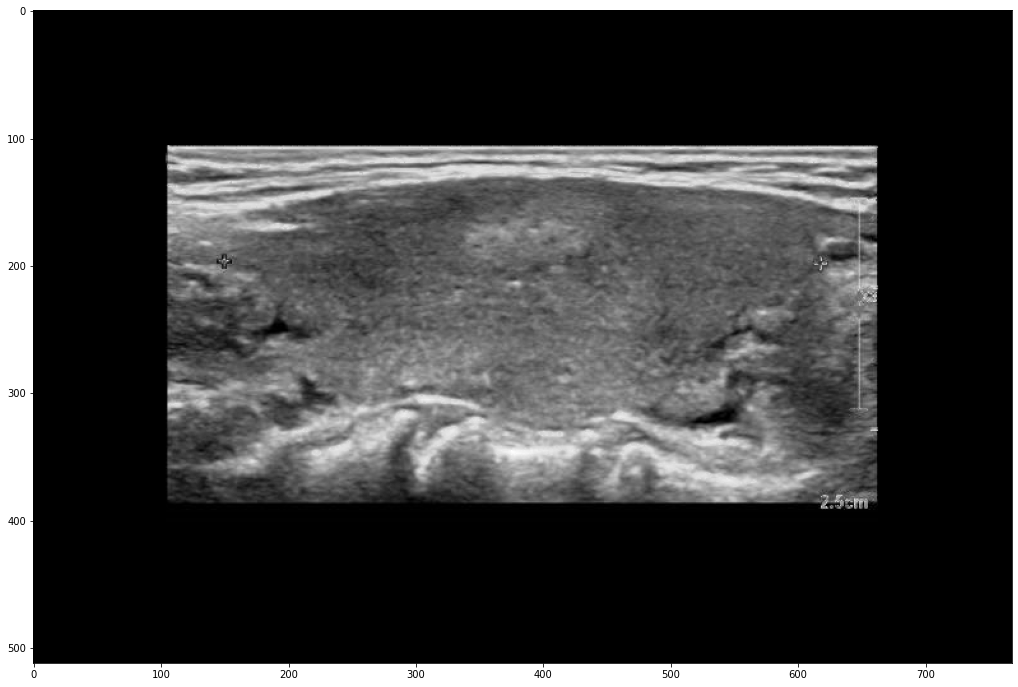

Vert flip:


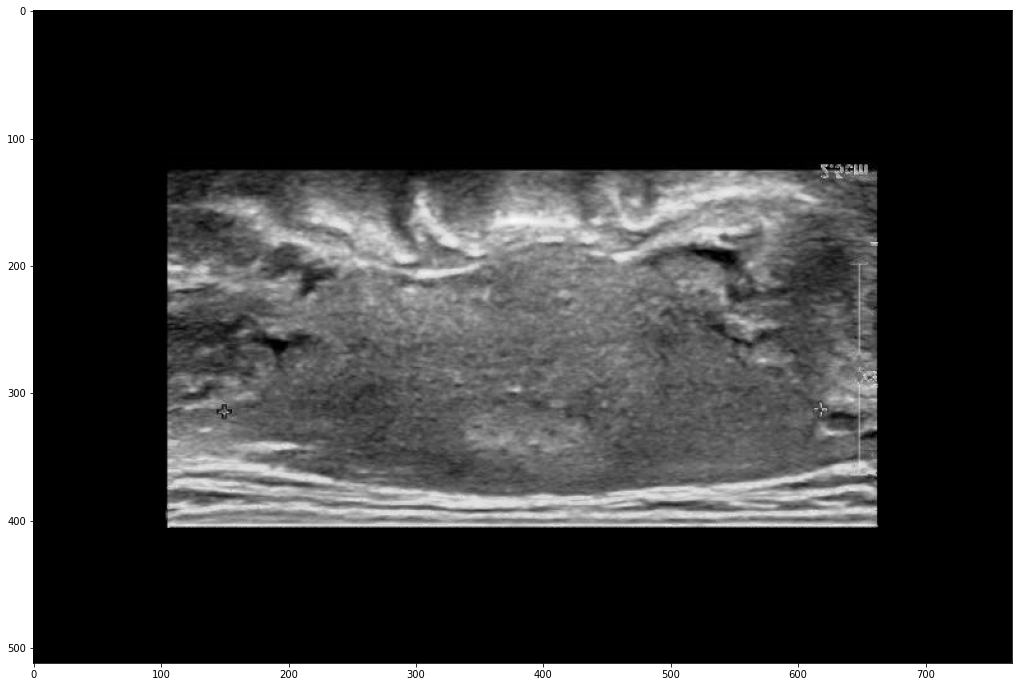

Horizontal flip:


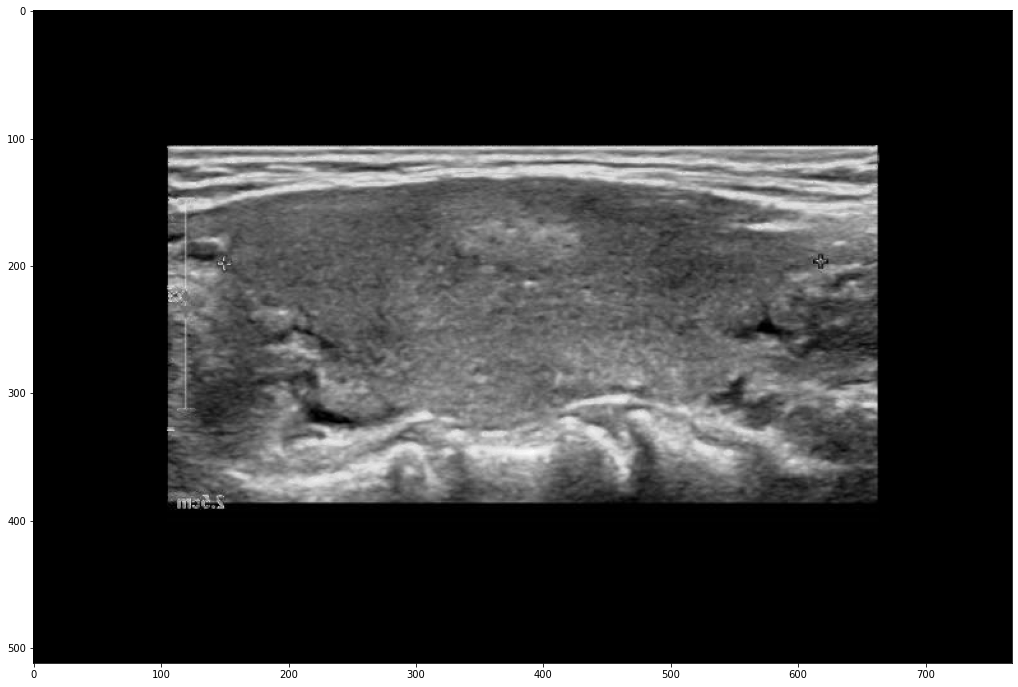

In [9]:

#display sample augmented image
print("Original Image:")
plt.imshow(X_train_augmented[0],'gray')
plt.show()

print("Vert flip:")
plt.imshow(X_train_augmented[len(X_train)],'gray')
plt.show()

print("Horizontal flip:")
plt.imshow(X_train_augmented[DataAugment],'gray')
plt.show()

(235, 1)
(235, 512, 768)
Original Image:


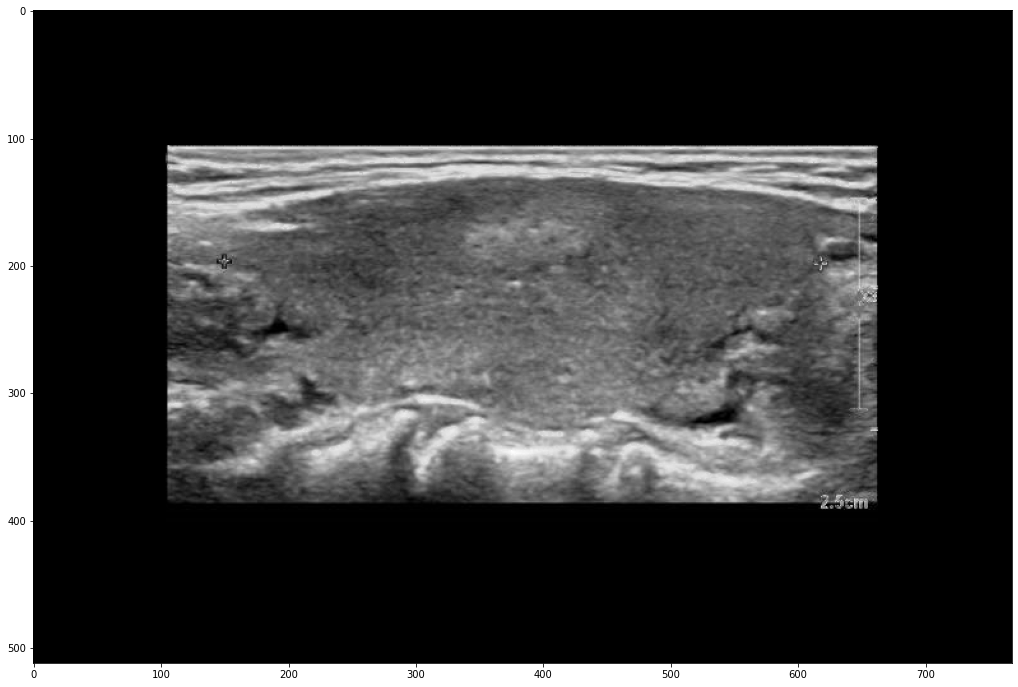

clockwise rotated:


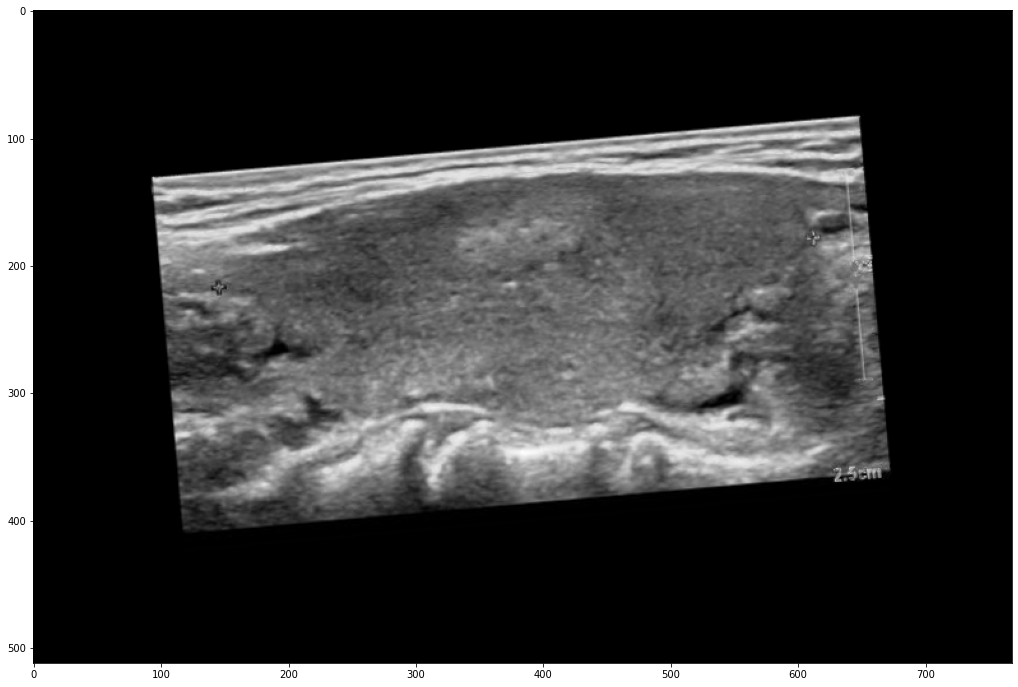

anticlockwise rotated:


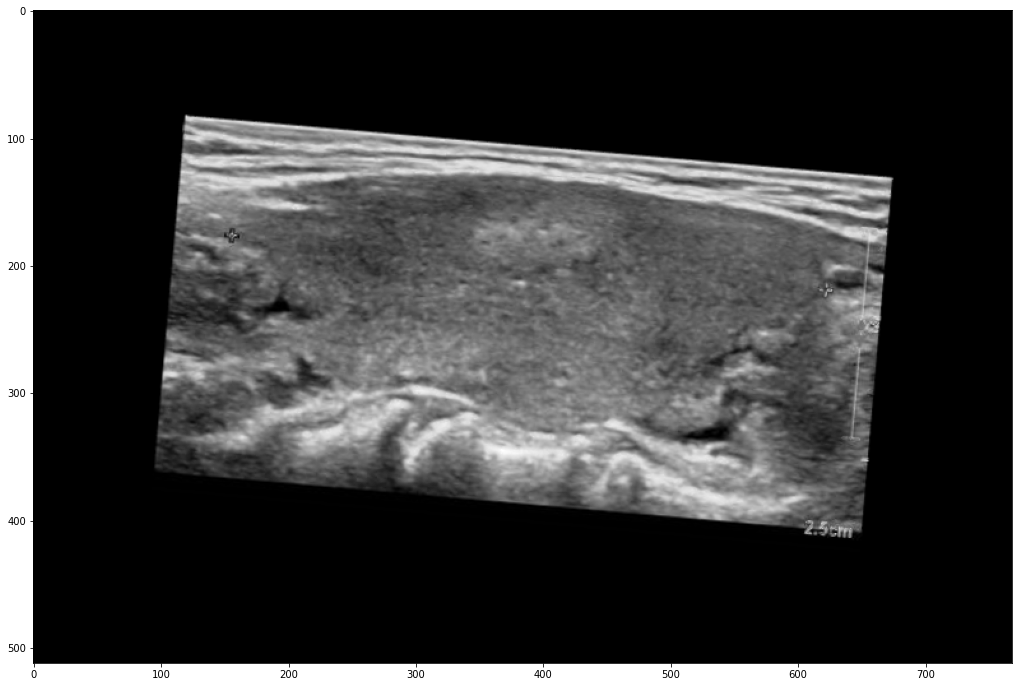

In [10]:

#adjusting y_train due to data augmentation
y_train_augmented=np.concatenate((y_train,y_train,y_train,y_train,y_train))

for i in range(len(X_train)):
        rotatedImg = rotate(X_train[i],angle=5)
        X_train_augmented=np.concatenate((X_train_augmented,np.expand_dims(rotatedImg, axis = 0)), axis = 0)

for i in range(len(X_train)):
        rotatedImg = rotate(X_train[i],angle=-5)
        X_train_augmented=np.concatenate((X_train_augmented,np.expand_dims(rotatedImg, axis = 0)), axis = 0)

print(y_train_augmented.shape)
print(X_train_augmented.shape)

print("Original Image:")
plt.imshow(X_train_augmented[0],'gray')
plt.show()

print("clockwise rotated:")
plt.imshow(X_train_augmented[len(X_train)*3],'gray')
plt.show()

print("anticlockwise rotated:")
plt.imshow(X_train_augmented[len(X_train)*4],'gray')
plt.show()

In [11]:
X_train_augmented = tf.expand_dims(X_train_augmented, axis=-1)
X_val = tf.expand_dims(X_val, axis=-1)
X_test = tf.expand_dims(X_test, axis=-1)



In [12]:
print(X_train_augmented.shape)
print(y_train_augmented.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(235, 512, 768, 1)
(235, 1)
(16, 512, 768, 1)
(16, 1)
(16, 512, 768, 1)
(16, 1)


In [13]:
from tensorflow.keras.models import load_model
        


model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(8, kernel_size=(3, 3), activation='relu',padding='same'),
    tf.keras.layers.Conv2D(8, kernel_size=(3, 3), activation='relu',padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2),strides=2),
    tf.keras.layers.Conv2D(16, kernel_size=(5, 5), activation='relu'),
    tf.keras.layers.Conv2D(16, kernel_size=(5, 5), activation='relu',kernel_regularizer=tf.keras.regularizers.l1(0.02), bias_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2),strides=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])




predictions = model(X_train_augmented[:1]).numpy()

tf.nn.softmax(predictions).numpy()

model.compile(optimizer='Adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary(line_length=100)







Model: "sequential"
____________________________________________________________________________________________________
Layer (type)                                 Output Shape                            Param #        
conv2d (Conv2D)                              (1, 512, 768, 8)                        80             
____________________________________________________________________________________________________
conv2d_1 (Conv2D)                            (1, 512, 768, 8)                        584            
____________________________________________________________________________________________________
max_pooling2d (MaxPooling2D)                 (1, 256, 384, 8)                        0              
____________________________________________________________________________________________________
conv2d_2 (Conv2D)                            (1, 252, 380, 16)                       3216           
_______________________________________________________________________

In [14]:
history=model.fit(X_train_augmented, y_train_augmented, epochs=30, validation_data=(X_val, y_val))
test_loss, test_acc =model.evaluate(X_test,  y_test, verbose=2)

print('\nTest accuracy:', test_acc)


Epoch 1/30
8/8 [==============================] - 6s 433ms/step - loss: 220.1962 - accuracy: 0.7021 - val_loss: 6.5582 - val_accuracy: 0.8125
Epoch 2/30
8/8 [==============================] - 2s 222ms/step - loss: 6.2261 - accuracy: 0.6638 - val_loss: 5.8436 - val_accuracy: 0.8750
Epoch 3/30
8/8 [==============================] - 2s 221ms/step - loss: 5.6621 - accuracy: 0.8511 - val_loss: 5.6755 - val_accuracy: 0.8750
Epoch 4/30
8/8 [==============================] - 2s 222ms/step - loss: 5.4011 - accuracy: 0.9149 - val_loss: 5.5487 - val_accuracy: 0.8750
Epoch 5/30
8/8 [==============================] - 2s 222ms/step - loss: 5.1217 - accuracy: 0.9532 - val_loss: 5.7715 - val_accuracy: 0.8750
Epoch 6/30
8/8 [==============================] - 2s 221ms/step - loss: 4.8835 - accuracy: 0.9915 - val_loss: 5.8746 - val_accuracy: 0.9375
Epoch 7/30
8/8 [==============================] - 2s 235ms/step - loss: 4.6891 - accuracy: 1.0000 - val_loss: 5.9368 - val_accuracy: 0.9375
Epoch 8/30
8/8 [==

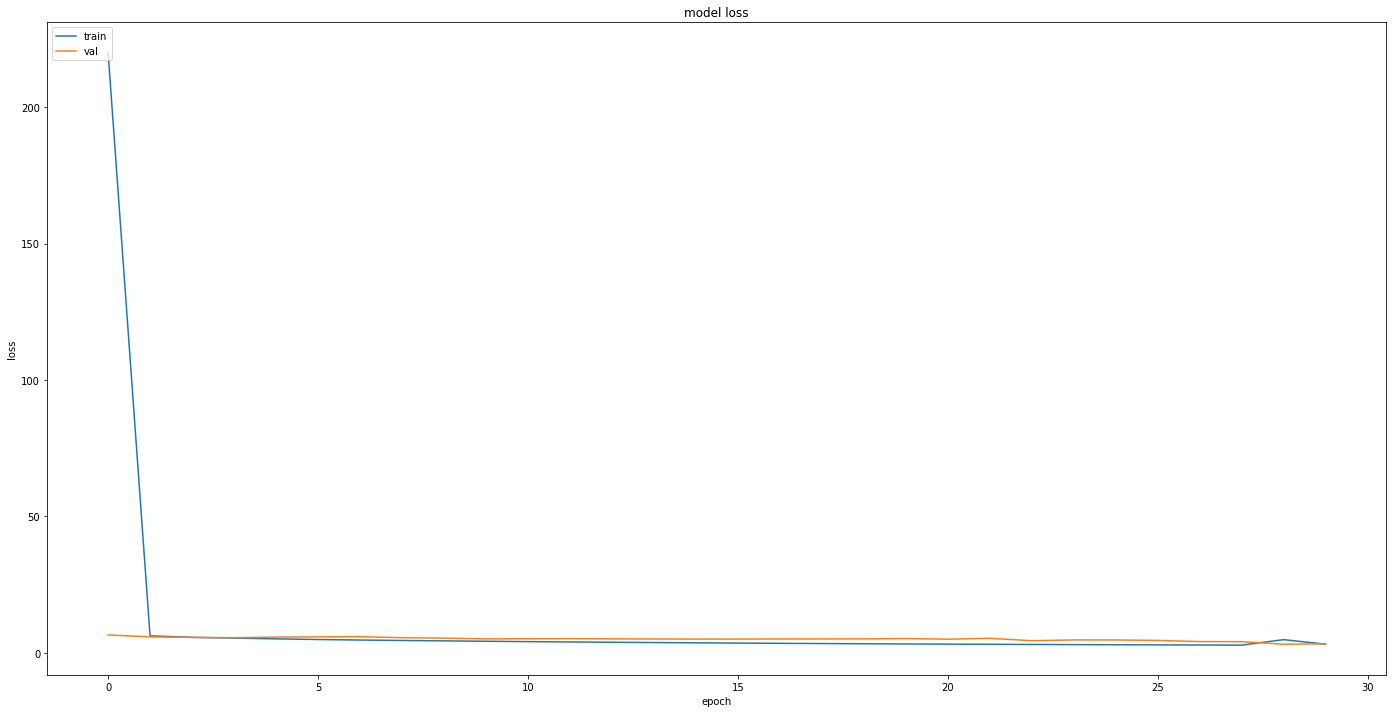

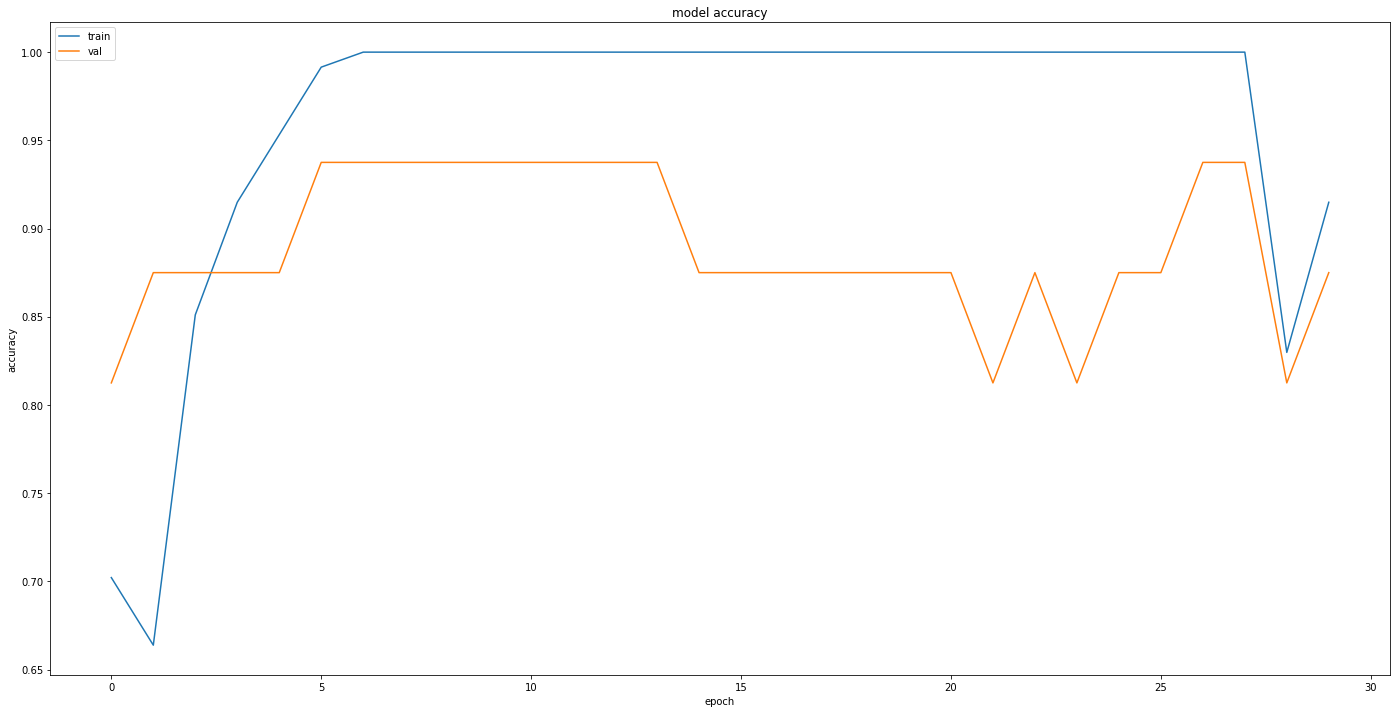

In [15]:
from matplotlib import pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left') 
plt.show()

In [16]:
from sklearn.metrics import f1_score, classification_report

y_pred = model.predict(X_test, verbose=1)


1/1 [==============================] - 0s 85ms/step


In [17]:
# print(pd.crosstab(y_test, y_pred.argmax(axis=1), rownames=['True'], colnames=['Predicted'], margins=True))
print(classification_report(y_test, y_pred.argmax(axis=1)))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.83      1.00      0.91        10
           2       0.00      0.00      0.00         1

    accuracy                           0.88        16
   macro avg       0.61      0.60      0.60        16
weighted avg       0.83      0.88      0.85        16



C:\Users\BRIAN\AppData\Roaming\Python\Python36\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [18]:
from sklearn.metrics import confusion_matrix
 
predicted=np.argmax(model.predict(X_test), axis=-1)
print("Predicted Results:", end=" ")
for i in predicted:
    print(i, end=" ")
    
print()
print("Actual Results:", end="  ")
expected=y_test
for i in expected:
    for j in i:
        print(j, end=" ")

print()
results = confusion_matrix(expected, predicted)
print(results)

Predicted Results: 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 0 
Actual Results:  1 1 2 0 1 1 1 0 0 1 0 1 1 1 1 0 
[[ 4  1  0]
 [ 0 10  0]
 [ 0  1  0]]


In [19]:
X_test_illustration = tf.squeeze(X_test, axis=-1)
print(X_test_illustration.shape)

(16, 512, 768)


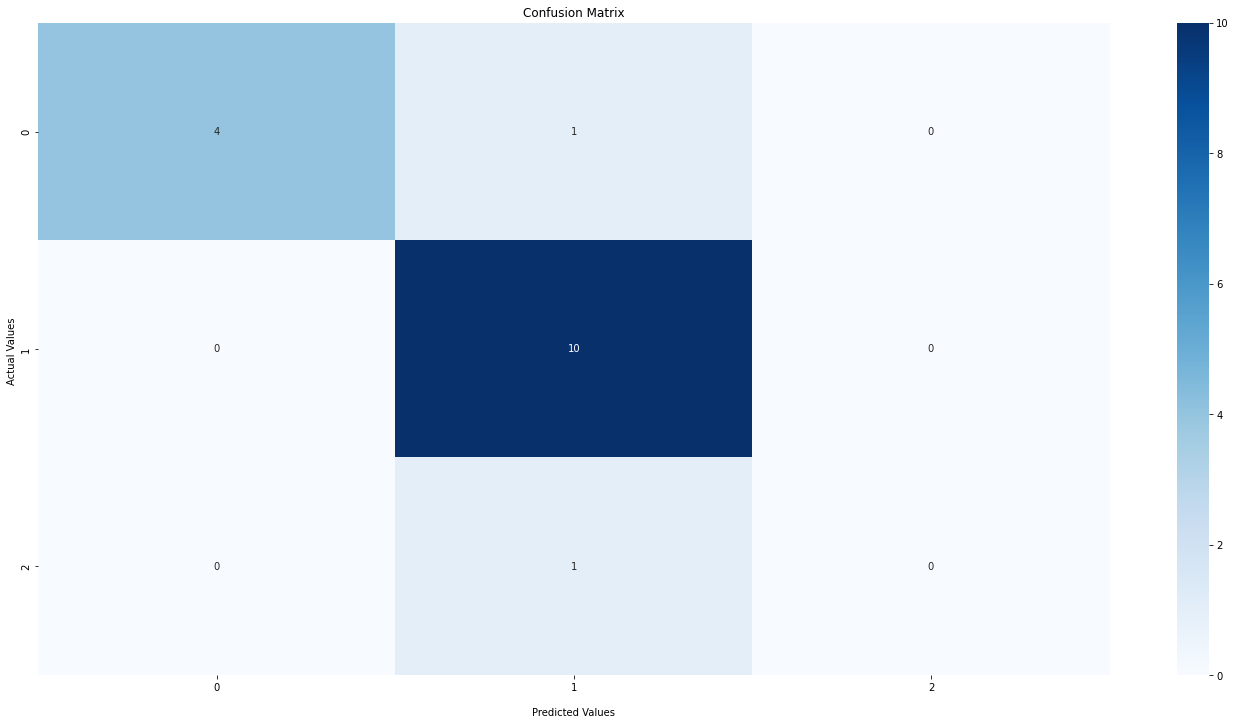

In [20]:
import seaborn as sns

ax = sns.heatmap(results, annot=True, cmap='Blues')

ax.set_title('Confusion Matrix')
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ')



## Display the visualization of the Confusion Matrix.
plt.show()

In [21]:
def get_class_prediction(model, x):
    pred = model.predict(x)
    if pred.shape[1] == 1:
        return (pred>0.5).astype(np.int8).squeeze(axis=-1)
    else:
        return pred.argmax(axis=1)

In [22]:
predicted=get_class_prediction(model, X_test)

NumOfImg=len(y_test)

print("Predicted Results:", end=" ")
for i in predicted:
    print(i, end=" ")
print()
print("Actual Results:  ", end="  ")
actual = y_test
for i in actual:
    for j in i:
        print(j, end=" ")
NumOfImg = len(actual)
ctr = 0
for i in range(NumOfImg):
    if(actual[i] != predicted[i]):
        ctr += 1
print("\nNumber of Correct Predictions:", NumOfImg-ctr, "of", NumOfImg)

Predicted Results: 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 0 
Actual Results:    1 1 2 0 1 1 1 0 0 1 0 1 1 1 1 0 
Number of Correct Predictions: 14 of 16


Incorrect Classification Report:


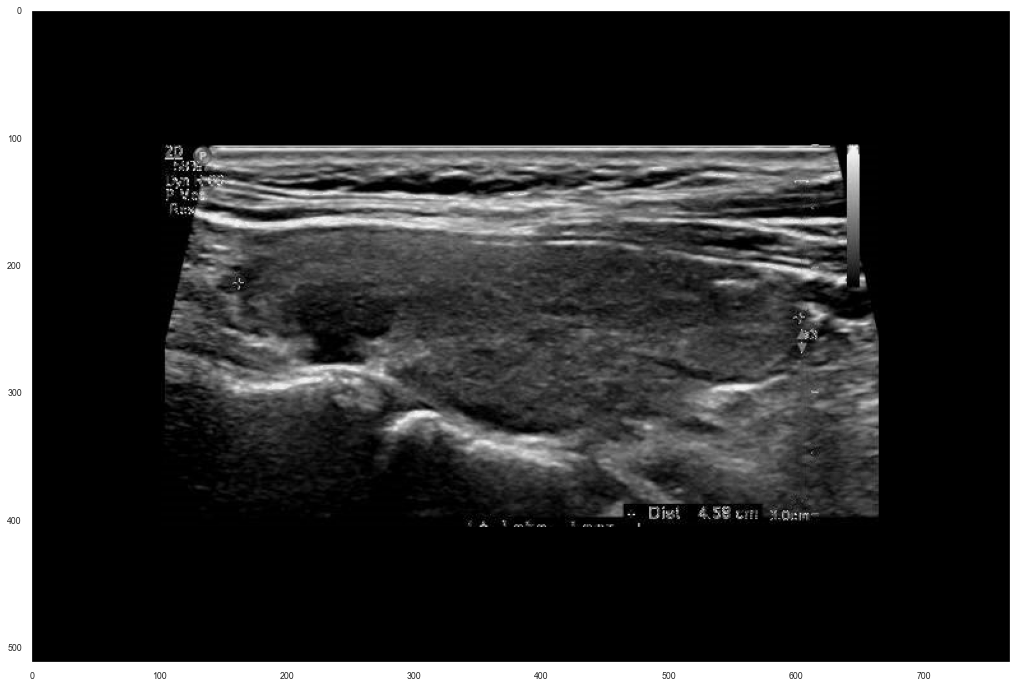

         Predicted label: 1
            Actual label: 2
              Image Path: ..\data\295\13.png


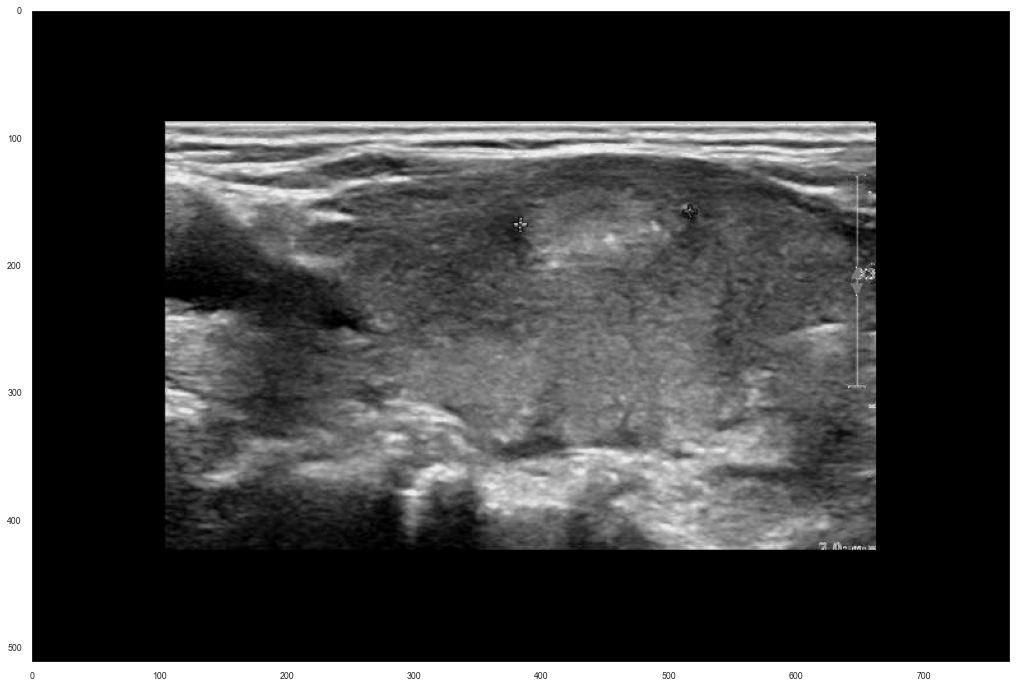

         Predicted label: 1
            Actual label: 0
              Image Path: ..\data\295\13.png


In [23]:
from termcolor import colored

sns.set(font_scale=0.8)
print(colored("Incorrect Classification Report:", attrs=['bold']))
for i in range(NumOfImg):
    if(actual[i] != predicted[i]):
        plt.figure(figsize=(20, 12))
        plt.grid(False)
        plt.imshow(X_test[i], 'gray')
        plt.show()
        

        
        WrongResults = "         Predicted label: "+str(predicted[i])
        CorrectResults = "            Actual label: "+str(actual[i][0])
        print(colored(WrongResults, 'red', attrs=['bold']))
        print(colored(CorrectResults, 'green', attrs=['bold']))
        print("              Image Path:",image_path)